In [ ]:
%load_ext autoreload
%autoreload 2

import time
# from auto_robot_design.pinokla.closed_loop_kinematics import closedLoopProximalMount
from testing_ground.singular_hell.prox_custom import closedLoopProximalMount_open_support

from auto_robot_design.pinokla.calc_criterion import search_workspace
from pinocchio.visualize import MeshcatVisualizer
import meshcat
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

import pinocchio as pin
from auto_robot_design.pinokla.closed_loop_kinematics import ForwardK
from auto_robot_design.pinokla.closed_loop_jacobian import jacobian_constraint

from auto_robot_design.description.builder import ParametrizedBuilder, DetailedURDFCreatorFixedEE, jps_graph2pinocchio_robot
from auto_robot_design.generator.restricted_generator.two_link_generator import TwoLinkGenerator

from auto_robot_design.generator.restricted_generator.two_link_generator import TwoLinkGenerator
from auto_robot_design.description.utils import draw_joint_point
import networkx as nx

from auto_robot_design.description.builder import add_branch
from auto_robot_design.description.kinematics import JointPoint

In [2]:
def angle_wrap(arr):
    # return (arr + np.pi) % (2 * np.pi) - np.pi
    return ((-arr + np.pi) % (2 * np.pi) - np.pi) * -1

In [3]:
# link_mounts = {
#     'L1': [[0., 0.], [0., -0.15], 'G', True],
#     'L2': [[0., -0.15], [0., -0.3], 'L1', False],
#     }
# equalities = [
#     # [[0.0, -0.074], 'L3', 'L6'],
#     # [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
#     [[0., -0.3], 'L2'],
# ]
# link_mounts = {
#     'L8': [[-0.1, 0.0], [-0.11151828996322964, -0.046192388155425125], 'G', True],
#     'L7': [[-0.11151828996322964, -0.046192388155425125], [-0.087, -0.087], 'L8', False],
#     'L5': [[-0.087, -0.087], [0.0, -0.22399999999999998], 'L7', False],
#     'L5_2': [[0.0, -0.22399999999999998], [-0.040807611844574876, -0.09851828996322964], 'L5', None],
#     'L5_3': [[-0.040807611844574876, -0.09851828996322964], [-0.087, -0.087], 'L5', None],
#     'L6': [[-0.040807611844574876, -0.09851828996322964], [0.0, -0.074], 'L5', False],
#     'L3': [[0.0, 0.0], [0.0, -0.074], 'G', True],
#     'L3_2': [[0.0, -0.074], [0.0, -0.148], 'L3', None],
#     'L3_3': [[0.0, -0.148], [0.0, 0.0], 'L3', None],
#     'L4': [[0.0, -0.148], [0.0, -0.3], 'L3', False],
#     'L4_2': [[0.0, -0.3], [0.0, -0.22399999999999998], 'L4', None],
#     'L4_3': [[0.0, -0.22399999999999998], [0.0, -0.148], 'L4', None],
#     }
# equalities = [
#     [[0.0, -0.074], 'L3', 'L6'],
#     [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
#     [[0.0, -0.3], 'L4'],
# ]

#DOES NOT WORK FOR KIN GRAPH CONVERSION, JOINTS OVERLAP
# link_mounts = {
# 'L6': [[-0.1, 0.0], [-0.15000000000000002, -0.11199999999999999], 'G', True],
# 'L5': [[-0.15000000000000002, -0.11199999999999999], [0.0, -0.22399999999999998], 'L6', False],
# 'L3': [[0.0, 0.0], [0.0, -0.148], 'G', True],
# 'L4': [[0.0, -0.148], [0.0, -0.22399999999999998], 'L3', False],
# 'L4_2': [[0.0, -0.22399999999999998], [0.0, -0.3], 'L4', None],
# 'L4_3': [[0.0, -0.3], [0.0, -0.148], 'L4', None],
# }
# equalities = [
# [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
# [[0.0, -0.3], 'L4'],
# ]


# 5 BAR
# base_w = 0.4
# knee_w = 0.6
# knee_h = 0.3
# tip_h = 0.55
# pr1 = [base_w/2, 0]
# pl1 = [-base_w/2, 0]

# pr2 = [knee_w/2, -knee_h]
# pl2 = [-knee_w/2, -knee_h]
# pc = [0, -tip_h]
# link_mounts = {1:[pr1, pl1, 0, None, -.15],
#               2:[pr1, pr2, 1, True],
#               3:[pr2, pc, 2, False],
#               4:[pl1, pl2, 1, True],
#               5:[pl2, pc, 4, False]}
# equalities = [[pc, 5, 3, 0.03]]
# trackpoints = [[pc, 5, 0.05]]


# TWO BAR
# base_w = 0.4
# knee_w = 0.6
# knee_h = 0.3
# tip_h = 0.55

# pr1 = [base_w/2, 0]
# pr2 = [knee_w/2, -knee_h]
# pl1 = [-base_w/2, 0]
# pc = [0, -tip_h]

# link_mounts = {#1:[pr1, pl1, 0, None],
#             1:[pr1, pr2, 0, True],
#             2:[pr2, pc, 1, True]}
# equalities = []
# trackpoints = [[pc, 2, 0.05]]

base_w = 0.4
knee_w = 0.6
knee_h = 0.3
tip_h = 0.55

pr1 = [base_w/2, 0]
pr2 = [knee_w/2, -knee_h]
pl1 = [-base_w/2, 0]
pc = [0, -tip_h]

link_mounts = {1:[pr1, pl1, 0, None],
            2:[pr1, pr2, 1, True],
            3:[pr2, pc, 2, True]}
equalities = []
trackpoints = [[pc, 3, 0.05]]

In [4]:
# # paths = {k:v[2] for k,v in link_mounts.items()}
# paths = [(k,v[2]) for k,v in link_mounts.items()]

# G = nx.Graph()
# # print(paths)

# for path in paths:
#     # print(path)
#     nx.add_path(G, path)

# for j in G.edges():
#     print(j)

# jaxis = np.array([0, 1, 0])

# tp = trackpoints[0]
# jpos = tp[0]
# name = tp[1]

# assert len(jpos) == 2
# jp_pos = np.array([jpos[0], 0, jpos[1]])
# current_jp = JointPoint(r=jp_pos, w=jaxis, name='EE', attach_endeffector=True)


# # Ginv = nx.line_graph(G)
# # Ginv.add_node('EE')
# G.add_edge('EE', name)
# Ginv = nx.line_graph(G)

# # nx.draw(G, node_size=500, with_labels=True)
# nx.draw(Ginv, node_size=500, with_labels=True)
# plt.show()

{0: 0, 1: 0, 2: 2, 3: 3}
0
2
3
JointPoint(r=array([0.2, 0. , 0. ]), w=array([0, 1, 0]), active=True, attach_ground=True, attach_endeffector=False, name='2-1', instance_counter=0)
JointPoint(r=array([ 0.3,  0. , -0.3]), w=array([0, 1, 0]), active=True, attach_ground=False, attach_endeffector=False, name='3-2', instance_counter=0)
JointPoint(r=array([ 0.  ,  0.  , -0.56]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=True, name='jEE', instance_counter=0)


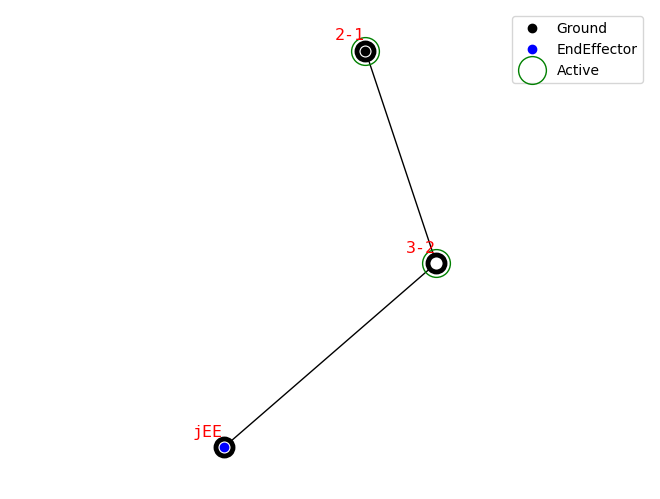

In [ ]:
from testing_ground.singular_hell.mj2jp import build_jp


graph_jp, _ = build_jp(link_mounts, equalities, trackpoints)

for j in graph_jp.nodes():
    print(j)

draw_joint_point(graph_jp)
plt.show()

# nx.draw(gj, node_size=500, with_labels=True)
# plt.show()

# nx.draw(gkin, node_size=500, with_labels=True)
# plt.show()

In [6]:
# gen = TwoLinkGenerator()
# graphs_and_cons = gen.get_standard_set()

# graph_jp, __ = graphs_and_cons[0]

link G
direct call
defining geom
link EE
direct call
defining geom
link 
direct call
defining geom
link 
direct call
defining geom
EE


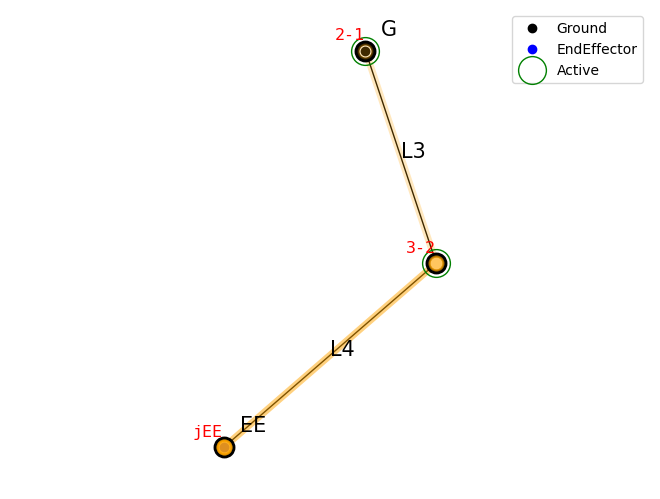

defining geom
defining geom


In [7]:
from auto_robot_design.description.mechanism import JointPoint2KinematicGraph
from auto_robot_design.description.utils import draw_links

is_showed=1

kinematic_graph = JointPoint2KinematicGraph(graph_jp)
EFFECTOR_NAME = kinematic_graph.EE.name
print(kinematic_graph.EE.name)

if is_showed:
    draw_links(kinematic_graph, graph_jp)
    plt.show()
# # draw_kinematic_graph(kinematic_graph)
# main_branch = kinematic_graph.define_main_branch()
# # draw_kinematic_graph(main_branch)
# kin_tree = kinematic_graph.define_span_tree()

# thickness = 0.04
# density = 2700 / 2.8
# for n in kinematic_graph.nodes():
#     n.thickness = thickness
#     n.density = density

# for j in kinematic_graph.joint_graph.nodes():
#     j.pos_limits = (-np.pi, np.pi)
#     if j.jp.active:
#         j.actuator = TMotor_AK80_9()
#     j.damphing_friction = (0.05, 0)
    
# kinematic_graph.define_link_frames()

kinematic_graph.define_main_branch()
kinematic_graph.define_span_tree()

kinematic_graph.define_link_frames()

In [8]:
for j in kinematic_graph.joint_graph.nodes():
    print(j.jp.name)
    # print(j.frame)
    print([l.name for l in j.links])
    print([l.frame for l in j.links])
# for

2-1
['G', 'L3']
[array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), array([[-0.9486833 ,  0.        ,  0.31622777,  0.2       ],
       [ 0.        ,  1.        ,  0.        ,  0.        ],
       [-0.31622777,  0.        , -0.9486833 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])]
3-2
['L3', 'L4']
[array([[-0.9486833 ,  0.        ,  0.31622777,  0.2       ],
       [ 0.        ,  1.        ,  0.        ,  0.        ],
       [-0.31622777,  0.        , -0.9486833 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), array([[-0.65493054, -0.        , -0.75568908,  0.3       ],
       [ 0.        ,  1.        , -0.        ,  0.        ],
       [ 0.75568908,  0.        , -0.65493054, -0.3       ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])]
jEE
['L4', 'EE']
[array([[-0.65493054, -0.        , -0.75568908,  0.3       ],
       [ 0.        ,  1.        , -0.        ,

In [ ]:
# gen = TwoLinkGenerator()

# # graphs_and_cons = gen.get_standard_set()
# # graph_jp, __ = graphs_and_cons[0]

# gen.build_standard_two_linker()
# graph_jp = gen.graph

# np.set_printoptions(precision=3, linewidth=300, suppress=True, threshold=10000)
# builder = ParametrizedBuilder(DetailedURDFCreatorFixedEE)

# # robo, robo_free = jps_graph2pinocchio_robot(graph_jp, builder)

# # q0 = closedLoopProximalMount_open_support(
# #     robo.model,
# #     robo.data,
# #     robo.constraint_models,
# #     robo.constraint_data,
# #     max_it=100,
# # )

In [119]:
# draw_joint_point(graph_jp)

In [120]:
# for j1,j2 in graph_jp.edges():
#     # if not kinematic_graph.EE in j.links:
#     # print([l.name for l in list(j.links)])
#     print(j1.name, j2.name)

# for j in graph_jp.nodes():
#     print(j)

In [9]:
builder = ParametrizedBuilder(DetailedURDFCreatorFixedEE)
robo, robo_free = jps_graph2pinocchio_robot(graph_jp, builder)



viz = MeshcatVisualizer(robo.model, robo.visual_model, robo.visual_model)
# viz.viewer = meshcat.Visualizer().open()
# viz.clean()
# viz.loadViewerModel()
viz.initViewer(loadModel=True)


link G
direct call
defining geom
link EE
direct call
defining geom
link 
direct call
defining geom
link 
direct call
defining geom
defining geom
defining geom
defining geom
defining geom
defining geom
defining geom
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7001/static/


In [ ]:
# q0 = np.array([0., 0.])
q0 = pin.neutral(robo.model)

# q0 = closedLoopProximalMount_open_support(
#     robo.model,
#     robo.data,
#     robo.constraint_models,
#     robo.constraint_data,
#     max_it=100,
# )

viz.display(q0)

In [11]:
def search_workspace_FK(
    model,
    data,
    effector_frame_name: str,
    base_frame_name: str,
    q_space: np.ndarray,
    actuation_model,
    constraint_models,
    constraint_data,
    viz=None, link_names=None, q_default=None
):
    """Iterate forward kinematics over q_space and try to minimize constrain value.

    Args:
        model (_type_): _description_
        data (_type_): _description_
        effector_frame_name (str): _description_
        base_frame_name (str): _description_
        q_space (np.ndarray): _description_
        actuation_model (_type_): _description_
        constraint_models (_type_): _description_
        viz (_type_, optional): _description_. Defaults to None.

    Returns:
        _type_: _description_
    """
    c = 0    
    q_start = pin.neutral(model)
    q_last_feas = q_start
    # if q_default is not None:
    #     q_start = q_default
    
    workspace_xyz = np.empty((len(q_space), 3))
    available_q = np.empty((len(q_space), len(q_start)))

    Js = []
    link_ids = []
    Ldsdq = []
    Lambdas = np.empty([len(q_space),2,2])
    # if link_names is not None:
    #     link_ids = [model.getFrameId(n) for n in link_names]
    # link_ids.append(model.getFrameId(effector_frame_name))
    for q_sample in q_space:
        q_start = angle_wrap(q_start)
        q_sample = angle_wrap(q_sample)
        # print(q_start[actuation_model.idqmot], q_sample, q_sample - q_start[actuation_model.idqmot])
        qmot_diff = q_sample - q_start[actuation_model.idqmot]
        # qmot_diff = q_sample - q_last_feas[actuation_model.idqmot]

        q_dict_mot = zip(actuation_model.idqmot, q_sample)
        for key, value in q_dict_mot:
            q_start[key] = value
        # q_start = angle_wrap(q_start)

        if len(constraint_models) > 0:
            print('WTF, CLOSED LOOP?')
        else:
            q3 = q_start
            q3 = angle_wrap(q3)
            q_start = angle_wrap(q_start)

            if viz:
                viz.display(q3)
                # time.sleep(0.005)

            # if q_default is not None:
            #     q_start = q_default
            # q_start = pin.neutral(model)
            pin.framesForwardKinematics(model, data, q3)
            id_effector = model.getFrameId(effector_frame_name)
            id_base = model.getFrameId(base_frame_name)
            effector_pos = data.oMf[id_effector].translation
            # base_pos = data.oMf[id_base].translation
            # print('pos',effector_pos)
            # transformed_pos = effector_pos - base_pos
            transformed_pos = effector_pos

            pin.computeJointJacobians(model, data, q3)  # precomputes all jacobians
            dsdq = []
            # link_ids = []
            # link_ids.append(id_effector)
            for lid in link_ids:
                dsdq.append(pin.getFrameJacobian(model, data, lid, pin.WORLD)) #TODO try diff coords LOCAL_WORLD_ALIGNED
            Ldsdq.append(dsdq)

            Jac = pin.computeFrameJacobian(model,data,q3,id_effector,pin.LOCAL_WORLD_ALIGNED)
            Jac = Jac[(0,2),:]

            M=pin.crba(model,data,q3)
            Lambda = np.linalg.inv(Jac @ np.linalg.inv(M) @ Jac.T)
            # Lambdas.append(Lambda)#[2,2])
            Lambdas[c] = Lambda#[2,2])

            # Jcs.append(Jconstraint)
            Js.append(Jac)
            workspace_xyz[c] = transformed_pos
            available_q[c] = q3
            c += 1


    return (workspace_xyz[0:c], available_q[0:c], Js, Lambdas)

In [12]:
EFFECTOR_NAME = "EE"
BASE_FRAME = "G"
LINK_FRAMES = ['L6','L5','L3','L4'] # ee is last

In [13]:
q_space_mot_1 = angle_wrap(np.linspace(-np.pi, np.pi, 80, endpoint=False))
q_space_mot_2 = angle_wrap(np.linspace(-np.pi, np.pi, 80, endpoint=False))
# q_space_mot_1 = np.concatenate((np.linspace(0, np.pi, 40, endpoint=False),
#                                np.linspace(-np.pi, 0, 40, endpoint=False)[::-1])) #best for no hist 150 it with reorder?
# q_space_mot_2 = np.concatenate((np.linspace(0, np.pi, 40, endpoint=False),
#                                np.linspace(-np.pi, 0, 40, endpoint=False)[::-1]))
# q_space_mot_2 = np.linspace(0, 2*np.pi, 80, endpoint=False)
# q_space_mot_1 = np.linspace(np.pi/2, np.pi, 5)
# q_space_mot_2 = np.linspace(np.pi, -np.pi, 20)

# q_space_mot_1 = np.asarray([0])
# q_space_mot_2 = np.asarray([np.pi/10, -0.559]) # Forw sing
# q_space_mot_1 = np.asarray([0])
# q_space_mot_2 = np.asarray([np.pi/10, np.pi/7.4]) # back sing
# q_space_mot_1 = np.asarray([0, -1.63])
# q_space_mot_2 = np.asarray([-0.52]) # back sing mega
# q_mot_double_space = list(product(q_space_mot_1, q_space_mot_2))

qm = []#np.empty(len(q_space_mot_1)*len(q_space_mot_2)) #q_mot_double_space
for i, m1 in enumerate(q_space_mot_1): 
    for j, m2 in enumerate(q_space_mot_2[::-1] if i%2 else q_space_mot_2):
        qm.append((m1, m2))
# for qmi in qm:
#     print(qmi)
q_mot_double_space = qm

# print(q0)
# print(angle_wrap(np.array([0,0.9*np.pi,np.pi,1.9*np.pi,2*np.pi])))

In [14]:
hasattr(viz.viewer, 'jupyter_cell') and viz.viewer.jupyter_cell()

In [15]:
workspace_xyz, available_q, jacs6d, Lambdas = search_workspace_FK(robo.model, robo.data, EFFECTOR_NAME, BASE_FRAME, np.array(
    q_mot_double_space), robo.actuation_model, robo.constraint_models, robo.constraint_data, viz, LINK_FRAMES)
print("Coverage q " + str(len(available_q)/(len(q_mot_double_space))))

Coverage q 1.0


In [ ]:
# import sys
# sys.path.append('d:/Soft/LGS-mujoco')
# sys.path.append('d:/Soft/LGS-mujoco/creative_mess')

# import LGS_mujoco
# from creative_mess import optim_2sem_sing
# from creative_mess.optim_2sem_sing import plot_fsing
from drafts.optim_2sem_sing import plot_colored_points, plot_fsing_tall, calc_least_SV



In [17]:
print(jacs6d)

[array([[ 0.04, -0.26],
       [ 0.4 ,  0.3 ]]), array([[ 0.06433922, -0.23566078],
       [ 0.41947457,  0.31947457]]), array([[ 0.09013137, -0.20986863],
       [ 0.43697946,  0.33697946]]), array([[ 0.11721743, -0.18278257],
       [ 0.45240677,  0.35240677]]), array([[ 0.1454304 , -0.1545696 ],
       [ 0.46566137,  0.36566137]]), array([[ 0.17459635, -0.12540365],
       [ 0.47666155,  0.37666155]]), array([[ 0.20453545, -0.09546455],
       [ 0.48533949,  0.38533949]]), array([[ 0.23506313, -0.06493687],
       [ 0.49164168,  0.39164168]]), array([[ 0.26599116, -0.03400884],
       [ 0.49552926,  0.39552926]]), array([[ 0.29712886, -0.00287114],
       [ 0.49697828,  0.39697828]]), array([[0.32828427, 0.02828427],
       [0.4959798 , 0.3959798 ]]), array([[0.3592653 , 0.0592653 ],
       [0.49253997, 0.39253997]]), array([[0.38988093, 0.08988093],
       [0.48667999, 0.38667999]]), array([[0.41994242, 0.11994242],
       [0.47843601, 0.37843601]]), array([[0.44926443, 0.14926443]

In [18]:
def calc_dqdmot(Jmot, Jfree, actuation_model):
    #init of constant
    Lidmot=actuation_model.idvmot
    Lidfree=actuation_model.idvfree
    nv_mot=len(Lidmot)

    # computation of dq/dqmot
    pinvJfree=np.linalg.pinv(Jfree)
    dq_dmot_no=np.concatenate((np.identity(nv_mot),-pinvJfree@Jmot)) 
    
    #re order dq/dqmot
    dq_dmot=dq_dmot_no.copy()
    dq_dmot[Lidmot]=dq_dmot_no[:nv_mot,:]
    dq_dmot[Lidfree]=dq_dmot_no[nv_mot:,:]
    return dq_dmot

In [19]:
singvals2ik = calc_least_SV(jacs6d)
sing_prox2ik = 1/singvals2ik

In [20]:
# jcons_cut = [ar[(0,2),:] for ar in jacsC6d]
# jcons_cut = jacsC6d
# jcons_cut = jacs6d

jcons_cut = [ar[(0,2),:] for ar in jacs6d] # seems like edges of ee space

singvals2ik = calc_least_SV(jcons_cut)
sing_prox2ik = 1/singvals2ik
# sing_prox2ik = singvals2ik
# lowest_clip = 1e-3
# highest_clip = 1e3
# sing_prox2ik = np.clip(sing_prox2ik, a_min=lowest_clip, a_max=highest_clip)

# list_dmotdq = []
# for i in range(len(jacsC6d)):
#     Jmot, Jfree = jacsC6d[i][0]
#     dqdmot = calc_dqdmot(Jmot, Jfree, robo.actuation_model)
#     dmotdq = np.linalg.pinv(dqdmot)
#     list_dmotdq.append(dmotdq)

# singvals2fk = calc_least_SV(list_dmotdq)
# sing_prox_fk = 1/singvals2fk

IndexError: index 2 is out of bounds for axis 0 with size 2

In [21]:
# print(available_q.shape)
print(sing_prox2ik)
print(np.min(sing_prox2ik), np.max(sing_prox2ik))

[4.47295219 4.49608243 4.54849217 ... 4.54849217 4.49608243 4.47295219]
4.472886205727902 18114.68200905881


In [22]:
def plot_fsing(available_xyz, motorspace_q, sing_prox2ik, is_log=False, color_lims=[1.5, 4], title="Близость сингулярности"):
    # color_lims = [1.5, 4]
    # color_lims = [.8, 1.5]
    dataq = np.asarray(motorspace_q)/np.pi*180
    dataee = np.asarray(available_xyz)
    fig = plt.figure(figsize=(10, 4.8), dpi=150) #6.4 4.8
    plt.suptitle(title)
    
    ax = fig.add_subplot(1, 2, 1)
    sc1 = plot_colored_points(ax, dataee[:,0], dataee[:,2], sing_prox2ik, 
    "Рабочее пространство", "X [м]", "Z [м]", is_log=is_log, add_cbar=0, 
    color_lims=color_lims, 
    )

    ax2 = fig.add_subplot(1, 2, 2)
    plot_colored_points(ax2, dataq[:,0], dataq[:,1], sing_prox2ik, 
    "Конфигурационное пространство", "Угол мотора 1, [градусы]", "Угол мотора 2 [градусы]", #[-180,180],[-180,180],
    # ticks=np.arange(-180, 181, step=45), 
    color_lims=color_lims, add_cbar=0,
    is_log=is_log)

    fig.subplots_adjust(right=.9)
    cax = fig.add_axes([0.91, 0.125, 0.02, 0.73])
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes('right', size='5%', pad=0.05)
    bar = fig.colorbar(mappable=sc1,cax=cax)#,ax=axs.ravel().tolist())

    bar = ax.collections[0].colorbar
    # if color_lims is not None:
    #     bar.set_ticks([color_lims[0], color_lims[1]])
    #     bar.set_ticklabels(['Дальше', 'Ближе'])
    # else:

    # bar.set_ticks([])
    bar.set_label('Близость сингулярности')

    # cax = fig.add_subplot(1,3,3)
    # cax = fig.add_axes([ax2.get_position().x1+0.01,ax2.get_position().y0,0.02,ax2.get_position().height])

    # bar = plt.colorbar(ax=ax, shrink=0.4)
    # plt.tight_layout()
    # bar=plt.colorbar()
    # plt.setp(bar.ax.get_yticklabels()[::2], visible=False)
    # for label in bar.ax.yaxis.get_ticklabels()[::2]:
    #     label.set_visible(False)

    plt.show()

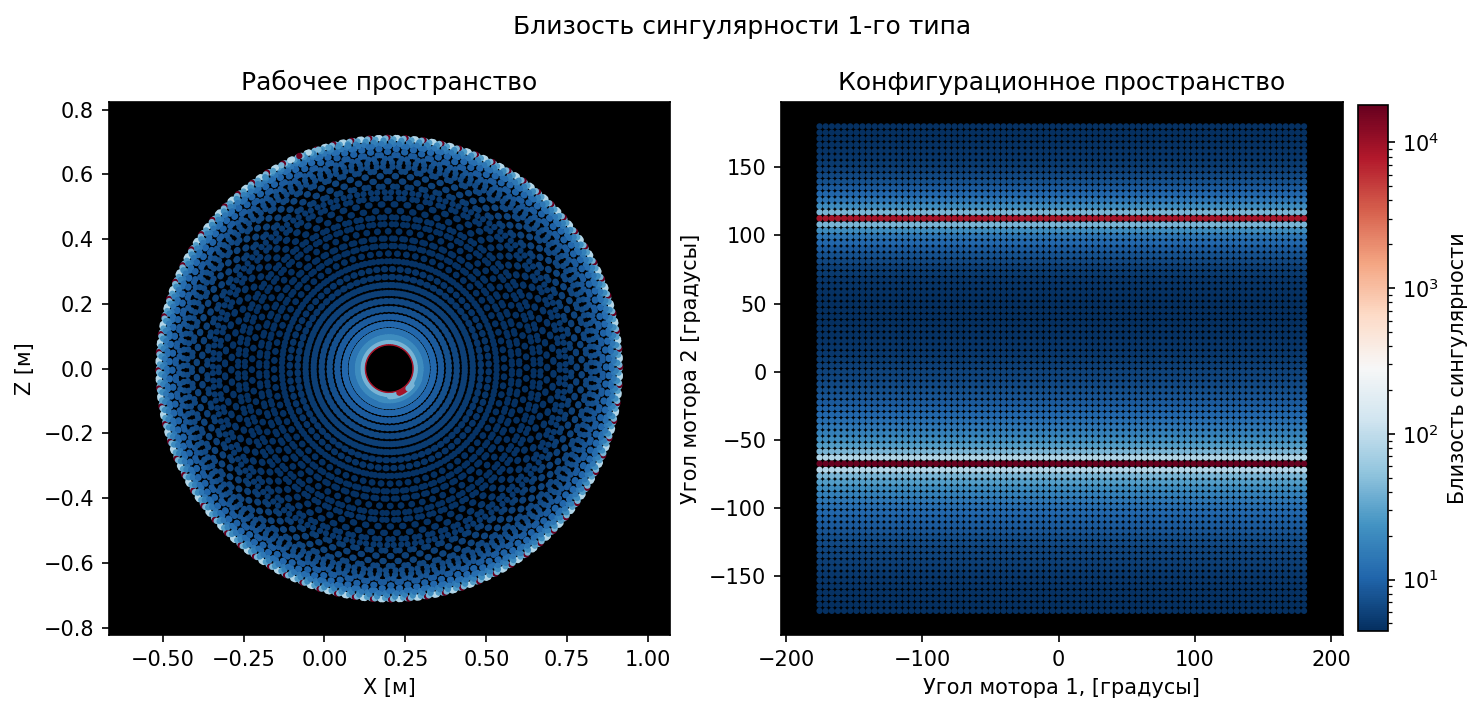

In [23]:
motorspace_q = np.asarray(available_q)[:,robo.actuation_model.idqmot]

# plot_fsing(workspace_xyz, motorspace_q, sing_prox2ik, is_log=1, color_lims=None)
plot_fsing(workspace_xyz, motorspace_q, sing_prox2ik, is_log=1, color_lims=None,title="Близость сингулярности 1-го типа")
# plot_fsing_tall(workspace_xyz, motorspace_q, sing_prox2ik, is_log=False)

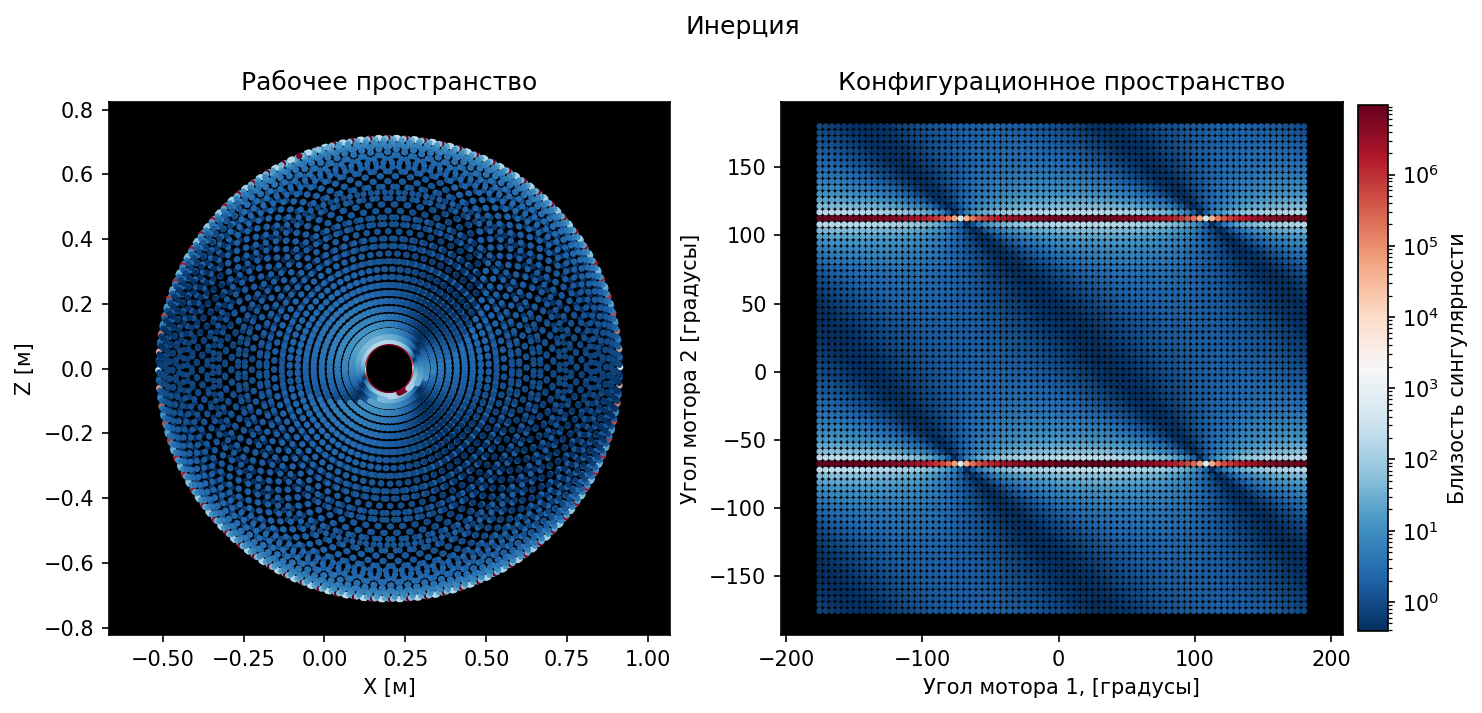

In [24]:
plot_fsing(workspace_xyz, motorspace_q, Lambdas[:,1,1], is_log=1, color_lims=None,title="Инерция")

In [25]:
print(Lambdas)

[[[1.29084075 0.69761083]
  [0.69761083 0.95270948]]

 [[1.34800845 0.63255772]
  [0.63255772 0.82851874]]

 [[1.40411458 0.56563552]
  [0.56563552 0.72509685]]

 ...

 [[1.31144977 0.6117825 ]
  [0.6117825  0.81776165]]

 [[1.24585673 0.66540293]
  [0.66540293 0.93067046]]

 [[1.17962889 0.71546977]
  [0.71546977 1.06392133]]]
